# Plot figures relative to town masks

### Packages and Directories

In [2]:
# --- Imports ---
import os
import sys
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import dask
from dask.distributed import Client, LocalCluster
from scipy.interpolate import griddata
from statsmodels.stats.multitest import fdrcorrection
import calendar
from datetime import datetime, timedelta
import cftime

from scipy import ndimage

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- Custom Functions ---
# sys.path.append('/home/portal/script/python/precip_Cristina/')                    # tintin
sys.path.append('/home/alice/Desktop/work/git/myISACcode/python/precip_Cristina')   # alice
import functions_analogues_PrMax as fanPM
import functions_analogues_LUCAFAMOSS as fan

In [3]:
# Define directories for data and figures
# # tintin
# CERRA_dir = '/work_big/users/clima/portal/CERRA/'
# ERA5_dir = '/work_big/users/clima/portal/ERA5/'
# CRCM5_dir = '/work_big/users/clima/portal/CRCM5-LE/'
# fig_dir = '/home/portal/figures/analogues/'

# alice
CERRA_dir = '/media/alice/Crucial X9/portal/data_CNR/CERRA/'
ERA5_dir = '/media/alice/Crucial X9/portal/data_CNR/ERA5/'
CRCM5_dir = '/media/alice/Crucial X9/portal/data_CNR/CRCM5-LE/'
fig_dir = '/home/alice/Desktop/CNR/ENCIRCLE/materiale_alice/figures/analogues/poster/'
diff_dir = './analogue_data/analogue_differences/'
pr_mask_dir = './analogue_data/pr_in_mask/'

### Parameters

In [4]:
# Variable
var_analogues = 'psl-zg500-std'  # Variable used to find the analogues, e.g. 'psl' for sea level pressure
var_BAM = 'psl'                  # Variable used for the BAM search

# Quantile and analogue number
qtl_LE = 0.99    # 0.99 (18 anaologues) or 0.999 (2 analogues)
if qtl_LE*100 % 1 == 0:
    qtl_LE_str = f"{int(qtl_LE*100)}pct"
else:
    qtl_LE_str = f"{qtl_LE*100:.1f}pct"

# Number of ensemble members
no_membs = 49

# List of members
list_membs = [name for name in os.listdir(CRCM5_dir + 'psl') if os.path.isdir(os.path.join(CRCM5_dir + 'psl', name))]
list_membs = sorted(list_membs)[:no_membs]  # Select the first 'no_membs' members


In [80]:
# Event
lselect = 'alertregions'  # 'Italy' or 'wide-region' or 'alert-regions'
no_node = 5
no_event = 23
event_origin = 'CRCM5-LE'  # 'ERA5' or 'CRCM5-LE'
str_event_ERA5 = f'node{no_node}-extreme{no_event}-{lselect}'  # 'Italy' or 'wide-region' or 'alert-regions'
str_event_BAM = f'BAM-node{no_node}-extreme{no_event}-{lselect}'  # 'Italy' or 'wide-region' or 'alert-regions'

# ERA5
df_events = pd.read_excel(CERRA_dir+'events_cum_on_above99_alertregions_CERRA.xlsx', sheet_name=no_node-1)
time_ERA5event = df_events['Time'].iloc[no_event-1] + pd.Timedelta('12h')
doy_ERA5event =  time_ERA5event.timetuple().tm_yday

# BAM
BAM_info, BAM_index = fanPM.get_best_model_analogue_info(no_node, no_event, var_BAM)
time = datetime.strptime(BAM_info['date'][BAM_index], "%Y-%m-%d")
time_BAMevent = cftime.DatetimeNoLeap(time.year, time.month, time.day, hour=0, minute=0, second=0)
doy_BAMevent = time_BAMevent.timetuple().tm_yday
member_BAMevent = BAM_info['member'][BAM_index]

# Define lon-lat box of event
box_event = fanPM.box_event_PrMax_alertregions(no_node,no_event)

# Defines the months for analogue selection
# ERA5
month_ERA5event = time_ERA5event.month
months_sel_ERA5 = [month_ERA5event-1, month_ERA5event, month_ERA5event+1]
month_names_ERA5 = [calendar.month_abbr[month] for month in months_sel_ERA5]
str_months_ERA5 = ''.join([name[0] for name in month_names_ERA5])
# BAM
month_BAMevent = time_BAMevent.month
months_sel_BAM = [month_BAMevent-1, month_BAMevent, month_BAMevent+1]
month_names_BAM = [calendar.month_abbr[month] for month in months_sel_BAM]
str_months_BAM = ''.join([name[0] for name in month_names_BAM])



### Upload analogue mean in different epochs

In [81]:
# Variable
varname = 'pr'
factor = 3600

# List epochs
list_year_ranges = [[1955, 1974], [2004, 2023], [2080, 2099]] # past [1955-1974], present [2004-2023], near-future [2030-2049], far future [2080-2099]
no_epochs = len(list_year_ranges)


In [82]:
# Upload analogue data
list_ds = []  # List to store difference datasets
for i in range(no_epochs):
    year_range = list_year_ranges[i]
    str_year_range = "-".join(str(x) for x in year_range)
    suffix_file = f"{varname}_{str_event_BAM}_{qtl_LE_str}_{str_year_range}_CRCM5_{no_membs}membs.nc"

    # Load analogue anomalies
    file = f'{diff_dir}analogues-{var_analogues}_{suffix_file}'
    if not os.path.exists(file):
        print(f'File {file} does not exist. Skipping epoch {i+1}.')
        continue
    ds = xr.open_dataset(file)
    list_ds.append(ds)

In [83]:
town_names, town_coords, town_masks, town_masks_expanded = fanPM.create_town_mask(list_ds[0].lon.values, list_ds[0].lat.values, no_node, no_event)
land_mask = fanPM.create_land_mask(list_ds[0].lon.values, list_ds[0].lat.values)

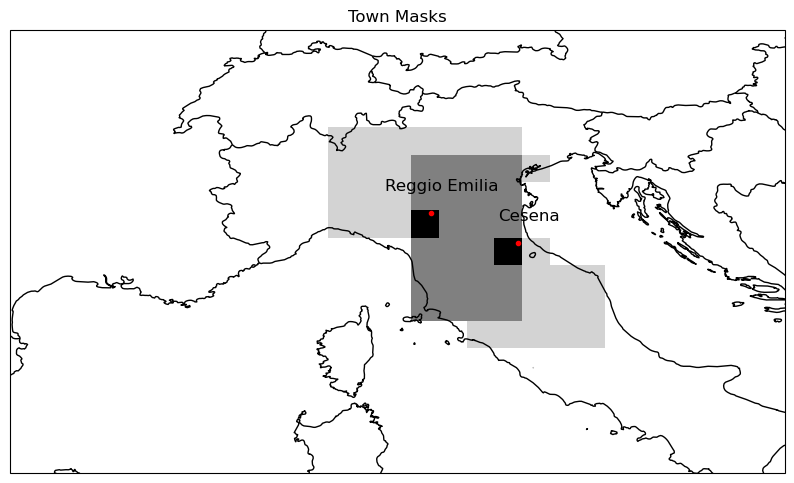

In [84]:
# Cartopy map of mask
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([3, 17, 40, 48], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.COASTLINE)

mask_all_expanded = np.zeros_like(land_mask.values, dtype=int)
mask_all_towns = np.zeros_like(land_mask.values, dtype=int)
for itown in range(len(town_names)):
    mask_all_towns += town_masks[itown].astype(int)  # Add the original town mask
    mask_all_expanded += town_masks_expanded[itown].astype(int)  # Add the expanded town mask
mask_all_expanded *= ((land_mask+mask_all_towns)>0).astype(int)  # Apply land mask to the combined town mask
cmap_expanded = ListedColormap(['white', 'lightgrey', 'grey'])
cmap_town = ListedColormap(['none', 'black'])
ax.pcolormesh(mask_all_expanded.lon.values, mask_all_expanded.lat.values, mask_all_expanded.values, transform=ccrs.PlateCarree(), cmap=cmap_expanded) #, colors=['w', 'lightgrey', 'grey']levels=[-0.5,0.5,1.5,2.5],
ax.pcolormesh(mask_all_towns.lon.values, mask_all_towns.lat.values, mask_all_towns.values, transform=ccrs.PlateCarree(), cmap=cmap_town) #, colors=['none', 'black'], levels=[-0.5,0.5,1.5],

for it in range(2):
    ax.plot(town_coords[it][1], town_coords[it][0], marker='o', color='red', markersize=3, transform=ccrs.PlateCarree())
    ax.text(town_coords[it][1]+0.2, town_coords[it][0]+0.4, town_names[it], fontsize=12, ha='center', transform=ccrs.PlateCarree())
plt.title('Town Masks')
plt.show()
fig.savefig(fig_dir + f'town_masks_7x7grid-and-land_{str_event_BAM}.png', dpi=300, bbox_inches='tight')

### Upload town data

In [79]:
# Parameters
# Variable
varname = 'pr'
factor = 3600

# List epochs
list_year_ranges = [[1955, 1974], [2004, 2023], [2080, 2099]] # past [1955-1974], present [2004-2023], near-future [2030-2049], far future [2080-2099]
no_epochs = len(list_year_ranges)

# List of ensemble sizes (by no members considered)
list_size_ens = [1, 2, 5, 10, 49]
str_size_ens = ''
for se in list_size_ens:
    str_size_ens += f'{se}-'
str_size_ens = str_size_ens[:-1] + 'membs'
print(str_size_ens)

# Towns
no_towns = len(town_names)
no_town_var = 3

1-2-5-10-49membs


In [60]:
# BAM regional mean precipitation
BAM_info, BAM_index = fanPM.get_best_model_analogue_info(no_node, no_event, var_BAM)
# mean_pr_BAM_in_mask = BAM_info['precip_in_BAM_20mm_mask'][BAM_index]

# Upload analogue data for mean precipitation in BAM mask per ensemble member
no_size = len(list_size_ens)
list_pr_town = []  # List to store mean precipitation for each ensemble member
list_pr_town_bysize = []  # List to store mean precipitation for different ensemble sizes
for j in range(no_epochs):
    year_range = list_year_ranges[j]
    str_year_range = "-".join(str(x) for x in year_range)
    # Load analogue values
    pr_town_epoch = np.ones((no_membs, no_towns, no_town_var)) * np.nan
    for im, memb in enumerate(list_membs):
        for itown in range(no_towns):
            file = f'{pr_mask_dir}towns/analogues-{var_analogues}_{town_names[itown]}-{varname}_{str_event_BAM}_{qtl_LE_str}_{str_year_range}_CRCM5_{memb}.nc'
            if not os.path.exists(file):
                print(f'File {file} does not exist. Skipping epoch {j+1}.')
                continue
            pr_town_epoch[im, itown, 0] = np.nanmean(xr.open_dataset(file)['pr_town'].values) * factor
            pr_town_epoch[im, itown, 1] = np.nanmean(xr.open_dataset(file)['pr_town_7x7'].values) * factor
            pr_town_epoch[im, itown, 2] = np.nanmean(xr.open_dataset(file)['pr_town_7x7_land'].values) * factor
    list_pr_town.append(pr_town_epoch)

    # Reconstruct samples of different ensemble sizes
    pr_town_epoch_size = np.ones((no_size, no_membs, no_towns, no_town_var)) * np.nan
    for isize in range(no_size):
        no_memb = list_size_ens[isize]
        if no_memb==1:
             pr_town_epoch_size[isize] = pr_town_epoch
        elif no_memb==no_membs:
            pr_town_epoch_size[isize] = np.nanmean(pr_town_epoch, axis=0)
        else:
            for irand in range(no_membs):
                random_indices = np.random.choice(no_membs, size=no_memb, replace=False)
                pr_town_epoch_size[isize, irand] = np.nanmean(pr_town_epoch[random_indices], axis=0)
    list_pr_town_bysize.append(pr_town_epoch_size)


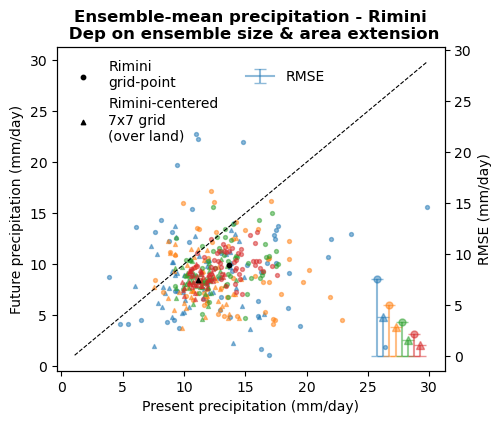

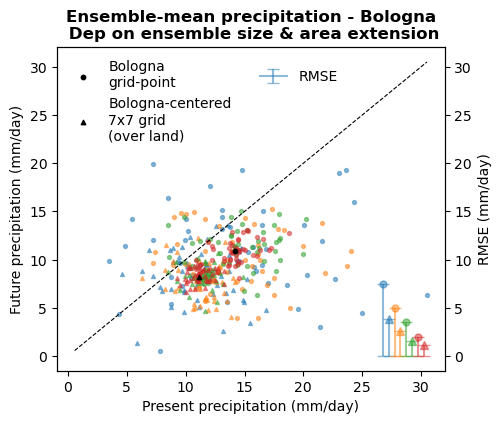

In [61]:
# Plot scatter plot of p_pres vs p_fut, once per ensemble size

# Violin plot setup
list_epoch_str = [f"{year_range[0]}-{year_range[1]}" for year_range in list_year_ranges]

for itown in range(no_towns):
    # Create a new figure for each town
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 4.2))
    ax.set_title(f"Ensemble-mean precipitation - {town_names[itown]}\n Dep on ensemble size & area extension", fontsize=12, weight="bold")

    min_val = np.inf
    max_val = -np.inf
    rmse_size = []
    colors = []
    for isize in range(no_size):
        # Get the data for the current epoch and ensemble size
        precip_pres = list_pr_town_bysize[1][isize,:,itown]
        precip_fut = list_pr_town_bysize[2][isize,:,itown]
        if list_size_ens[isize] != no_membs:
            precip_pres_true = list_pr_town_bysize[1][-1,:,itown]
            precip_fut_true = list_pr_town_bysize[2][-1,:,itown]
            rmse_size.append(np.sqrt(np.nanmean((precip_pres - precip_pres_true)**2 + (precip_fut - precip_fut_true)**2, axis=0)))
    
        # Plot the scatter plot of current vs future precip for the current ensemble size
    
        if list_size_ens[isize] == no_membs:
            ax.scatter(precip_pres[0,0], precip_fut[0,0], label=f'{town_names[itown]}\ngrid-point', s=10, marker='o', color='k', alpha=1)
            # ax.scatter(precip_pres[1,1], precip_fut[1,1], marker='x', s=10, color='k', alpha=1)
            ax.scatter(precip_pres[2,2], precip_fut[2,2], label=f'{town_names[itown]}-centered\n7x7 grid\n(over land)' ,marker='^', s=10, color='k', alpha=1)
        else:
            ax.scatter(precip_pres[:,0], precip_fut[:,0], marker='o', s=8, alpha=0.5)
            colors.append(ax.collections[-1].get_facecolor()[0])
            # ax.scatter(precip_pres[:3,1], precip_fut[:3,1], marker='x', s=8, color=colors[-1], alpha=0.5)
            ax.scatter(precip_pres[:,2], precip_fut[:,2], marker='^', s=8, color=colors[-1], alpha=0.5)

        # Plot the 1:1 line
        min_val = np.amin([min_val, np.amin(precip_pres), np.amin(precip_fut)])
        max_val = np.amax([max_val, np.amax(precip_pres), np.amax(precip_fut)])
    
    ax.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=0.8) 
    min_val_ceil = np.ceil(min_val)
    min_val_floor = np.floor(min_val)
    x_start = np.ceil(max_val) - no_size + 1
    for isize in range(no_size-1):
        for ivar in [0,2]:
            if isize == 0 and ivar == 0:
                ax.errorbar(x_start + isize + (ivar-1)/4, min_val_floor+rmse_size[isize][ivar]/2, yerr=rmse_size[isize][ivar]/2, color=colors[isize], capsize=4, label='RMSE')
            else:
                ax.errorbar(x_start + isize + (ivar-1)/4, min_val_floor+rmse_size[isize][ivar]/2, yerr=rmse_size[isize][ivar]/2, color=colors[isize], capsize=4)

        ax.plot(x_start + isize - 1/4, min_val_floor+rmse_size[isize][0], marker='o', color=colors[isize], markersize=5)
        ax.plot(x_start + isize + 1/4, min_val_floor+rmse_size[isize][2], marker='^', color=colors[isize], markersize=6)


    # Ticks and labels
    ax.set_xlabel('Present precipitation (mm/day)')
    ax.set_ylabel('Future precipitation (mm/day)')
    ax.yaxis.set_ticks_position('both')
    ax_new = ax.twinx()
    ax_new.set_ylim(ax.get_ylim()- min_val_floor)
    ax_new.set_ylabel('RMSE (mm/day)')
    ax.legend(ncol=2, frameon=False, loc='upper left') 
    plt.show()
    
    # Save the figure
    fig.savefig(f"{fig_dir}{varname}_ens-mean_{town_names[itown]}_analogues-{var_analogues}_{str_event_BAM}_{qtl_LE_str}_CRCM5_{str_size_ens}.png", bbox_inches='tight', dpi=300)
    fig.savefig(f"{fig_dir}{varname}_ens-mean_{town_names[itown]}_analogues-{var_analogues}_{str_event_BAM}_{qtl_LE_str}_CRCM5_{str_size_ens}.pdf", bbox_inches='tight')